# New amplifier: gain check

Sweeps the HP8673H 2-3 GHz directly into the E4403B with the new amplifier in the
path (amplifier output -> E4403B input, same physical setup as the "amplifier gain
check" step in `cw_odmr.ipynb`) and computes `gain_db(f) = measured_power_dbm(f) -
input_power_dbm`. Generator power set to **-40 dBm** for now (per user request --
raise later once the new amplifier's linear range is known, same caution as the
-40 dBm default used elsewhere once an amplifier is in the chain).

Uses `HP8673H.frequency_sweep()`, which already builds in settling time: a longer
`initial_settle_s` (default 1.0 s) after the first big frequency jump, plus a
smaller nonzero `settle_s` (default 0.05 s) between each step -- `settle_s=0` is
known to produce spurious false dips from a step-to-step GPIB/generator race (see
`hp8673h.py`'s docstring and `notes.md`), so both are left at their safe defaults
below rather than sped up.

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt

from hp8673h import HP8673H
from e4403b import E4403B

# See notes.md -- GPIB bus numbering isn't stable, confirm with
# pyvisa.ResourceManager().list_resources() if these don't match.
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

os.makedirs("data", exist_ok=True)

## Gain sweep (-40 dBm input)

In [ ]:
GAIN_START_HZ = 2.0e9
GAIN_STOP_HZ = 3.0e9
GAIN_STEP_HZ = 5e6
INPUT_POWER_DBM = -40.0

sa.set_center_span((GAIN_START_HZ + GAIN_STOP_HZ) / 2, GAIN_STOP_HZ - GAIN_START_HZ)
freqs_hz, output_power_dbm = gen.frequency_sweep(
    sa, GAIN_START_HZ, GAIN_STOP_HZ, GAIN_STEP_HZ, power_dbm=INPUT_POWER_DBM,
)
gain_db = output_power_dbm - INPUT_POWER_DBM

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, gain_db)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("gain (dB)")
ax.set_title(f"new amplifier gain ({INPUT_POWER_DBM:.0f} dBm input)")
fig.tight_layout()

print(f"gain: mean {gain_db.mean():.2f} dB, min {gain_db.min():.2f} dB, "
      f"max {gain_db.max():.2f} dB, flatness (max-min) {np.ptp(gain_db):.2f} dB")

np.savetxt(
    "data/new_amplifier_gain_m40dbm.csv",
    np.column_stack([freqs_hz, output_power_dbm, gain_db]),
    delimiter=",", header="frequency_hz,output_power_dbm,gain_db", comments="",
)

## Compression point (0 dBm drive)

**Physical setup change:** at -40 dBm input the gain sweep above went straight into the E4403B, but 0 dBm in plus the amplifier's linear gain (mean value from the sweep above) would land well above what's safe to feed the analyzer directly. Route the amplifier output through a coupler instead -- output -> isolator -> coupler -> terminated load, with the coupler's **forward** sample port going to the E4403B (same setup as `cw_odmr.ipynb`'s "maximum output power" step) -- so the analyzer only sees a small coupled fraction of the real output power.

`COUPLING_DB` below is the 20 dB value from that same coupler's datasheet -- confirm it's the same physical coupler before trusting `estimated_output_dbm`. Coarser 20 MHz step here (vs. 5 MHz for the gain sweep) since this is another smooth curve, not something with sharp features to resolve. Compare `estimated_gain_db` here to the linear gain measured above -- a lower number means real compression.

In [ ]:
MAXP_START_HZ = 2.0e9
MAXP_STOP_HZ = 3.0e9
MAXP_STEP_HZ = 20e6
INPUT_POWER_DBM_0 = 0.0
COUPLING_DB = 20.0  # forward-coupled port of the output coupler, from datasheet

sa.set_center_span((MAXP_START_HZ + MAXP_STOP_HZ) / 2, MAXP_STOP_HZ - MAXP_START_HZ)
freqs_hz_0, coupled_power_dbm = gen.frequency_sweep(
    sa, MAXP_START_HZ, MAXP_STOP_HZ, MAXP_STEP_HZ, power_dbm=INPUT_POWER_DBM_0,
)
estimated_output_dbm = coupled_power_dbm + COUPLING_DB
estimated_gain_db = estimated_output_dbm - INPUT_POWER_DBM_0

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz_0 / 1e9, estimated_output_dbm)
i_max = np.argmax(estimated_output_dbm)
ax.axvline(freqs_hz_0[i_max] / 1e9, color="C1", ls="--",
           label=f"max: {estimated_output_dbm[i_max]:.2f} dBm @ {freqs_hz_0[i_max]/1e9:.4f} GHz")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("estimated output power (dBm)")
ax.set_title(f"new amplifier output power ({INPUT_POWER_DBM_0:.0f} dBm drive)")
ax.legend()
fig.tight_layout()

print(f"coupled power at analyzer: min {coupled_power_dbm.min():.2f} dBm, "
      f"max {coupled_power_dbm.max():.2f} dBm")
print(f"estimated actual output power: min {estimated_output_dbm.min():.2f} dBm, "
      f"max {estimated_output_dbm.max():.2f} dBm at {freqs_hz_0[i_max]/1e9:.4f} GHz")
print(f"estimated gain at 0 dBm drive: min {estimated_gain_db.min():.2f} dB, "
      f"max {estimated_gain_db.max():.2f} dB, mean {estimated_gain_db.mean():.2f} dB")
print(f"(compare to {gain_db.mean():.2f} dB mean linear gain measured at "
      f"{INPUT_POWER_DBM} dBm drive -- a lower number here means real compression/saturation)")

np.savetxt(
    "data/new_amplifier_max_output_0dbm.csv",
    np.column_stack([freqs_hz_0, coupled_power_dbm, estimated_output_dbm, estimated_gain_db]),
    delimiter=",",
    header="frequency_hz,coupled_power_dbm,estimated_output_dbm,estimated_gain_db",
    comments="",
)

## Cleanup

In [ ]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Analysis from saved data

Reproduces both plots straight from the saved CSVs (`data/new_amplifier_gain_m40dbm.csv`, `data/new_amplifier_max_output_0dbm.csv`) rather than the in-memory sweep variables above -- no live instrument connection needed, can be re-run standalone.

gain: mean 29.74 dB, min 22.59 dB, max 31.11 dB, flatness (max-min) 8.52 dB


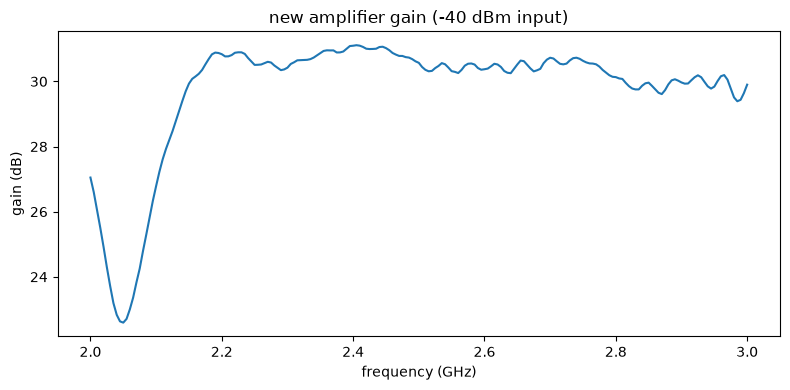

In [2]:
gain_data = np.genfromtxt("data/new_amplifier_gain_m40dbm.csv", delimiter=",", names=True)
gain_freqs_hz = gain_data["frequency_hz"]
gain_db_saved = gain_data["gain_db"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gain_freqs_hz / 1e9, gain_db_saved)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("gain (dB)")
ax.set_title("new amplifier gain (-40 dBm input)")
fig.tight_layout()

print(f"gain: mean {gain_db_saved.mean():.2f} dB, min {gain_db_saved.min():.2f} dB, "
      f"max {gain_db_saved.max():.2f} dB, flatness (max-min) {np.ptp(gain_db_saved):.2f} dB")

estimated actual output power: min 20.73 dBm, max 27.44 dBm at 2.2200 GHz
estimated gain at 0 dBm drive: min 20.73 dB, max 27.44 dB, mean 25.65 dB
(compare to 29.74 dB mean linear gain at -40 dBm drive -- a lower number here means real compression/saturation)


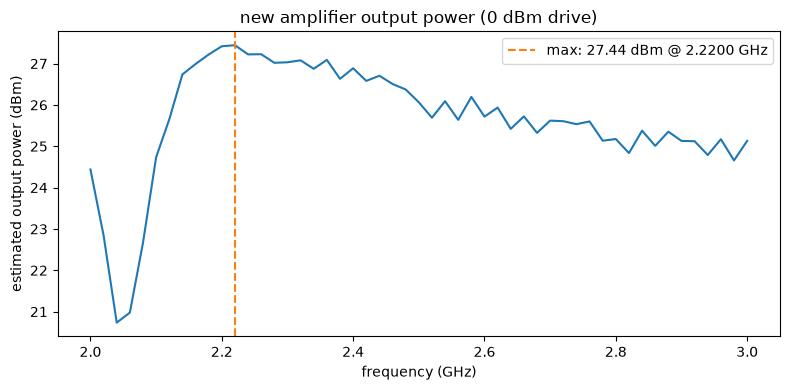

In [3]:
maxp_data = np.genfromtxt("data/new_amplifier_max_output_0dbm.csv", delimiter=",", names=True)
maxp_freqs_hz = maxp_data["frequency_hz"]
estimated_output_dbm_saved = maxp_data["estimated_output_dbm"]
estimated_gain_db_saved = maxp_data["estimated_gain_db"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(maxp_freqs_hz / 1e9, estimated_output_dbm_saved)
i_max_saved = np.argmax(estimated_output_dbm_saved)
ax.axvline(maxp_freqs_hz[i_max_saved] / 1e9, color="C1", ls="--",
           label=f"max: {estimated_output_dbm_saved[i_max_saved]:.2f} dBm @ "
                 f"{maxp_freqs_hz[i_max_saved]/1e9:.4f} GHz")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("estimated output power (dBm)")
ax.set_title("new amplifier output power (0 dBm drive)")
ax.legend()
fig.tight_layout()

print(f"estimated actual output power: min {estimated_output_dbm_saved.min():.2f} dBm, "
      f"max {estimated_output_dbm_saved.max():.2f} dBm at "
      f"{maxp_freqs_hz[i_max_saved]/1e9:.4f} GHz")
print(f"estimated gain at 0 dBm drive: min {estimated_gain_db_saved.min():.2f} dB, "
      f"max {estimated_gain_db_saved.max():.2f} dB, mean {estimated_gain_db_saved.mean():.2f} dB")
print(f"(compare to {gain_db_saved.mean():.2f} dB mean linear gain at -40 dBm drive -- "
      "a lower number here means real compression/saturation)")